<a href="https://colab.research.google.com/github/ai-ic/ml-ufpa/blob/main/decision_stump/ai_decision_stump.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir no Colab"/></a>

# Exemplo de Decision Stump (árvore de decisão de um único nível)

Exemplo de decision stump usando os conjuntos de treino/teste com as características Comprimento (Length) e Peso (Weight).

Obs: uma tradução literal de "stump" seria "toco" (toco de árvore), mas não soa bem.

## Importações

In [1]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt

## Definição do classificador `DecisionStump`

In [2]:
@dataclass(frozen=True)
class DecisionStump:
    """Um classificador binário que testa uma característica contra um limiar."""

    feature_index: int
    threshold: float
    label_at_or_below_threshold: int
    label_above_threshold: int

    def predict(self, features: npt.ArrayLike) -> npt.NDArray[np.int_]:
        """Classifica as linhas de uma matriz de características."""
        feature_array = np.asarray(features, dtype=float)
        selected_feature = feature_array[:, self.feature_index]
        return np.where(
            selected_feature <= self.threshold,
            self.label_at_or_below_threshold,
            self.label_above_threshold,
        )

## Funções auxiliares e de treinamento

In [3]:
def majority_label(labels: npt.NDArray[np.int_]) -> int:
    """Retorna o rótulo binário mais comum; escolhe 0 em caso de empate."""
    # Como os rótulos são só 0 ou 1, np.sum(labels) conta quantos rótulos são 1.
    # Se essa contagem for maior que a metade do total, a maioria é 1; senão, é 0.
    # int(...) converte o resultado de True/False (bool) para 1/0 (int).
    return int(np.sum(labels) > len(labels) / 2)


In [4]:
def fit_decision_stump(
    features: npt.ArrayLike, labels: npt.ArrayLike
) -> tuple[DecisionStump, float]:
    """Treina o melhor classificador binário de uma característica e um limiar."""
    feature_array = np.asarray(features, dtype=float)
    # reshape(-1) "achata" o array de rótulos para garantir que ele seja
    # unidimensional (uma lista simples de 0s e 1s), não importa o formato de entrada.
    label_array = np.asarray(labels, dtype=int).reshape(-1)

    if feature_array.ndim != 2 or len(feature_array) != len(label_array):
        raise ValueError("features deve ser uma matriz 2-D com uma linha por rótulo")
    # np.isin(array, [0, 1]) verifica, elemento a elemento, se cada rótulo é 0 ou 1.
    if len(feature_array) == 0 or not np.all(np.isin(label_array, [0, 1])):
        raise ValueError("labels deve ser não vazio e conter apenas 0 e 1")

    best_stump = None
    # float("inf") representa "infinito": qualquer erro real encontrado
    # será menor que isso, então o primeiro stump testado sempre "vence" a comparação inicial.
    best_error = float("inf")

    # IDEIA PRINCIPAL DO ALGORITMO:
    # Um decision stump escolhe UMA característica (coluna) e UM limiar (threshold)
    # que dividem os dados em dois grupos ("<= limiar" e "> limiar"), tentando
    # separar as classes 0 e 1 da melhor forma possível.
    # Para achar o melhor limiar de cada característica, testamos como candidatos
    # os pontos médios entre valores consecutivos ORDENADOS dessa característica
    # (não há necessidade de reordenar os rótulos, pois usamos máscaras booleanas
    # para comparar cada valor original da característica com o limiar).
    for feature_index in range(feature_array.shape[1]):
        # Pega todos os valores desta característica (uma coluna da matriz).
        values = feature_array[:, feature_index]
        # np.unique já retorna os valores ORDENADOS e sem repetição.
        unique_values = np.sort(np.unique(values))
        # Os candidatos a limiar ficam "no meio do caminho" entre cada par de
        # valores ordenados consecutivos (ex.: valores 10 e 12 -> limiar candidato 11).
        thresholds = (unique_values[:-1] + unique_values[1:]) / 2
        for threshold in thresholds:
            # left_mask é um array de True/False: True onde o valor da
            # característica é <= limiar. Essa "máscara booleana" permite
            # selecionar de uma vez todas as amostras de cada lado do limiar.
            left_mask = values <= threshold
            stump = DecisionStump(
                feature_index=feature_index,
                threshold=float(threshold),
                # O rótulo previsto para cada lado do limiar é o rótulo
                # majoritário (mais frequente) entre as amostras daquele lado.
                label_at_or_below_threshold=majority_label(label_array[left_mask]),
                # ~left_mask inverte a máscara (troca True por False e vice-versa),
                # selecionando assim o lado oposto ("> limiar").
                label_above_threshold=majority_label(label_array[~left_mask]),
            )
            # Mede o erro deste stump: proporção de previsões que não batem com o rótulo real.
            error = float(np.mean(stump.predict(feature_array) != label_array))
            if error < best_error:
                best_stump = stump
                best_error = error

    if best_stump is None:
        raise ValueError("pelo menos uma característica deve ter dois valores distintos")
    return best_stump, best_error


In [5]:
def accuracy(stump: DecisionStump, features: npt.ArrayLike, labels: npt.ArrayLike) -> float:
    """Retorna a proporção de amostras classificadas corretamente."""
    # Compara, elemento a elemento, a previsão do stump com o rótulo verdadeiro;
    # np.mean sobre um array de True/False dá a fração de acertos (a acurácia).
    return float(np.mean(stump.predict(features) == np.asarray(labels, dtype=int)))


## Função de visualização

In [6]:
def plot_decision_stump(
    train_features: npt.ArrayLike,
    train_labels: npt.ArrayLike,
    test_features: npt.ArrayLike,
    test_labels: npt.ArrayLike,
    stump: DecisionStump,
    feature_names: tuple[str, str],
) -> None:
    """Mostra as amostras de treino/teste e o limiar aprendido a partir dos dados de treino."""
    train_features_array = np.asarray(train_features, dtype=float)
    test_features_array = np.asarray(test_features, dtype=float)
    train_labels_array = np.asarray(train_labels, dtype=int)
    test_labels_array = np.asarray(test_labels, dtype=int)

    for label, color in ((0, "tab:blue"), (1, "tab:orange")):
        train_mask = train_labels_array == label
        test_mask = test_labels_array == label
        plt.scatter(
            train_features_array[train_mask, 0],
            train_features_array[train_mask, 1],
            color=color,
            edgecolors="black",
            label=f"treino classe {label}",
            s=80,
        )
        plt.scatter(
            test_features_array[test_mask, 0],
            test_features_array[test_mask, 1],
            color=color,
            marker="s",
            edgecolors="black",
            label=f"teste classe {label}",
            s=80,
        )

    if stump.feature_index == 0:
        plt.axvline(stump.threshold, color="black", linestyle="--", label="limiar")
    else:
        plt.axhline(stump.threshold, color="black", linestyle="--", label="limiar")
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title("Decision stump treinado no conjunto de treino")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

## Dados de treino e teste

In [7]:
feature_names = ("Length", "Weight")
train_features = np.array(
    [[12, 3.2], [10, 0.5], [14, 2.8], [14, 2.4], [13, 1.8], [13.8, 1.5], [11, 1]]
)
train_labels = np.array([0, 1, 0, 0, 1, 0, 1])
test_features = np.array([[13, 3.1], [9, 0.8], [12.3, 1.4], [10, 2.3]])
test_labels = np.array([0, 0, 1, 1])

## Treinamento do decision stump

In [8]:
stump, train_error = fit_decision_stump(train_features, train_labels)
print(f"Característica selecionada: {feature_names[stump.feature_index]}")
print(f"Melhor limiar: {stump.threshold:.2f}")
print(
    f"Regra: se {feature_names[stump.feature_index]} <= {stump.threshold:.2f}, "
    f"prever {stump.label_at_or_below_threshold}; caso contrário, "
    f"prever {stump.label_above_threshold}."
)

Característica selecionada: Length
Melhor limiar: 11.50
Regra: se Length <= 11.50, prever 1; caso contrário, prever 0.


## Avaliação nos conjuntos de treino e teste

In [9]:
print("Predições de treino:", stump.predict(train_features))
print(f"Acurácia de treino: {1 - train_error:.1%}")
print("Predições de teste: ", stump.predict(test_features))
print(f"Acurácia de teste:  {accuracy(stump, test_features, test_labels):.1%}")

Predições de treino: [0 1 0 0 0 0 1]
Acurácia de treino: 85.7%
Predições de teste:  [0 1 0 1]
Acurácia de teste:  50.0%


## Visualização do resultado

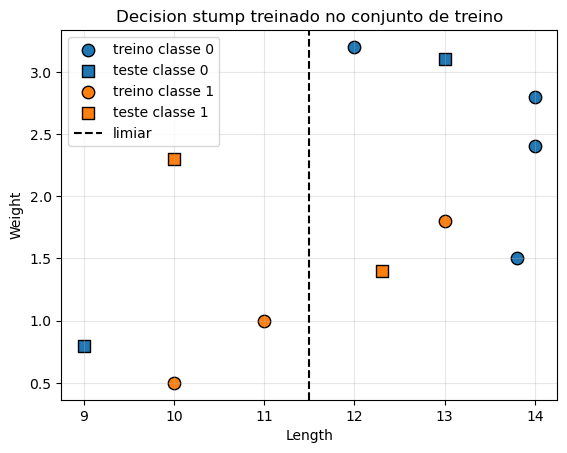

In [10]:
plot_decision_stump(
    train_features,
    train_labels,
    test_features,
    test_labels,
    stump,
    feature_names,
)